Median proportion of ground truth genes found for Subgraphia on Wastewater simulation: 0.9684999999999999
Median path length for Subgraphia on Wastewater simulation: 8211.0
Peak RSS for SubGraphia: 95.02 GB
Median proportion of ground truth genes found for Sarand on Wastewater: 0.583
Median path length for Sarand on Wastewater: 10864.0
   Subgraphia  Argcontextprofiler DNF  Sarand 94%
0        3.43                    1.89     363.531


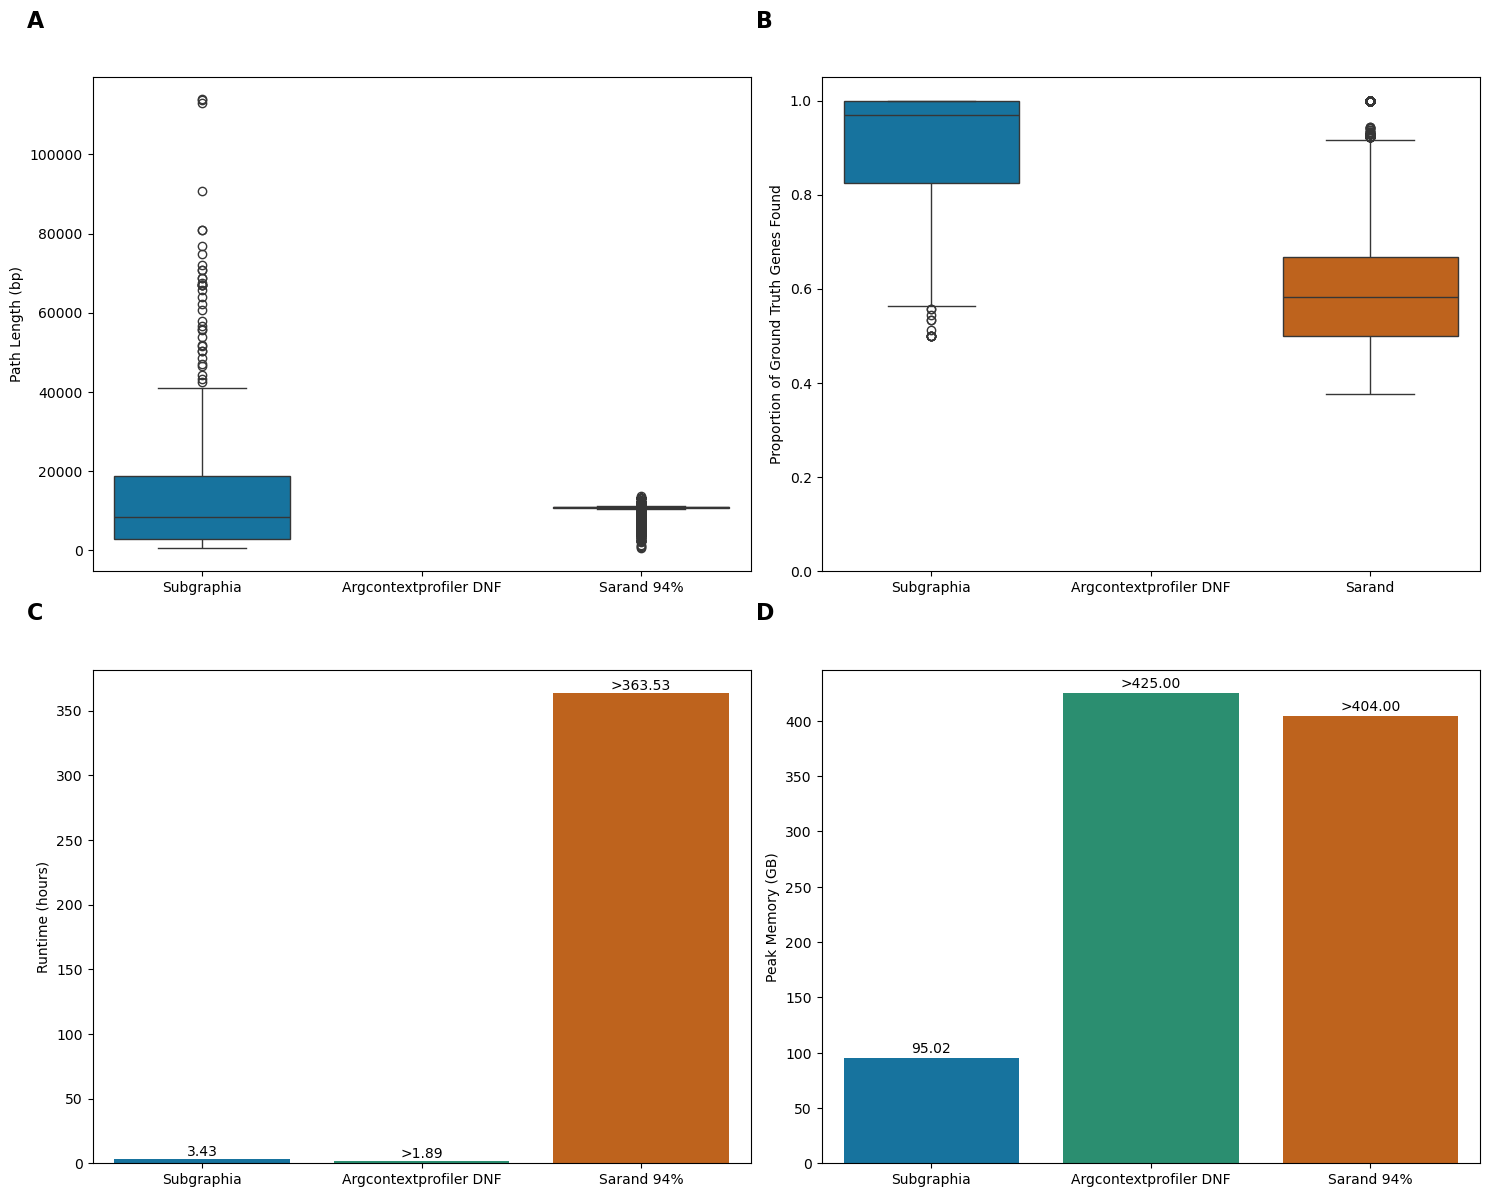

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# benchmarking figures for wastewater data

# read in Subgraphia data
## proportion-query-genes-found
fai_subgraphia_ww = pd.read_csv('../fai_correctness/ww_SR_fai_out.tsv', sep='\t')
# for instances where there are duplicate "queried_path" entries, take the higher "proportion-query-genes-found" value
fai_subgraphia_ww=fai_subgraphia_ww.sort_values(by='proportion-query-genes-found', ascending=False).drop_duplicates(subset='queried_path', keep='first')

fai_subgraphia_ww['Dataset'] = 'Wastewater'
fai_subgraphia_ww['Tool'] = 'Subgraphia'
## print median proportion-query-genes-found for Subgraphia on ZymoBIOMICS Mock Community
median_proportion_query_genes_found_subgraphia_ww = fai_subgraphia_ww['proportion-query-genes-found'].median()
print(f"Median proportion of ground truth genes found for Subgraphia on Wastewater simulation: {median_proportion_query_genes_found_subgraphia_ww}")


## length 
subgraphia_ww_summarized = pd.read_csv('../summarized_metadata/ww_SR_summarized.tsv', sep='\t')

# filter lengths >120kbp 
subgraphia_ww_summarized = subgraphia_ww_summarized[subgraphia_ww_summarized['path_length']<120000]

# keep only the "length" and "dataset" columns
subgraphia_ww_lengths = subgraphia_ww_summarized[['path_length', 'dataset']]
# rename "path_length" column to "length"
subgraphia_ww_lengths = subgraphia_ww_lengths.rename(columns={'path_length': 'length'})

# print median path length
median_length_subgraphia_ww = subgraphia_ww_lengths['length'].median()
print(f"Median path length for Subgraphia on Wastewater simulation: {median_length_subgraphia_ww}")

## runtime (hours)
subG_time = 3.43

## memory (GB)

subG_trace = pd.read_csv('subgraphia_ww_trace.tsv', sep='\t')
# remove rows with "-" in the "peak_rss" column
subG_trace = subG_trace[subG_trace['peak_rss'] != '-']
# convert "peak_rss" column to numeric
subG_trace['peak_rss'] = pd.to_numeric(subG_trace['peak_rss'], errors='coerce')
peak_RSS_subg = subG_trace['peak_rss'].max() / (1024 * 1024 * 1024)  # convert from bytes to GB
print(f"Peak RSS for SubGraphia: {peak_RSS_subg:.2f} GB")




# read in Argcontextprofiler data
## proportion-query-genes-found
proportion_query_genes_found_AGCP_ww = "NA"

## length
AGCP_lengths = "NA"

## runtime (hours)
AGCP_time = 1.89

## memory (GB)
AGCP_mem = 425


# read in Sarand data - 94% complete 267/286
## proportion-query-genes-found
fai_sarand_ww = pd.read_csv('sarand_ww_fai_out.tsv', sep='\t')
# for instances where there are duplicate "queried_path" entries, take the higher "proportion-query-genes-found" value
fai_sarand_ww=fai_sarand_ww.sort_values(by='proportion-query-genes-found', ascending=False).drop_duplicates(subset='queried_path', keep='first')

fai_sarand_ww['Dataset'] = 'Wastewater'
fai_sarand_ww['Tool'] = 'Sarand 94% complete'
# print median proportion-query-genes-found for Sarand on Wastewater
median_proportion_query_genes_found_sarand_ww = fai_sarand_ww['proportion-query-genes-found'].median()
print(f"Median proportion of ground truth genes found for Sarand on Wastewater: {median_proportion_query_genes_found_sarand_ww}")

## length
sarand_length_ww = pd.read_csv('sarand_ww_lengths.tsv', sep='\t', header=None, names=['name', 'length'])
sarand_length_ww['dataset'] = 'Wastewater'
## print median path length
median_length_sarand_ww = sarand_length_ww['length'].median()
print(f"Median path length for Sarand on Wastewater: {median_length_sarand_ww}")

## runtime (hours)
sar_time = 363.531

## memory (GB)
sar_mem = 404

# combine data into query_genes_found_df, length_df, runtime_df, memory_df for plotting

#create list of subgraphia query genes found, argcontextprofiler query genes found, and sarand query genes found
subg_query_genes_found = fai_subgraphia_ww['proportion-query-genes-found']
# add a NA value to the argcontextprofiler 
argconpro_genes_found = proportion_query_genes_found_AGCP_ww
sarand_genes_found = fai_sarand_ww['proportion-query-genes-found']
# combine lists to create query_genes_found_df
query_genes_found_df = pd.DataFrame({
    'Subgraphia': subg_query_genes_found,
    'Argcontextprofiler DNF': np.nan,  # add a NaN value for Argcontextprofiler
    'Sarand': sarand_genes_found
})

# create lists of subgraphia lengths, argcontextprofiler lengths, and sarand lengths
subg_lengths = subgraphia_ww_lengths['length']
argconpro_lengths = AGCP_lengths
sarand_lengths = sarand_length_ww['length']
# combine lists to create length_df
length_df = pd.DataFrame({
    'Subgraphia': subg_lengths,
    'Argcontextprofiler DNF': np.nan,  # add a NaN value for Argcontextprofiler
    'Sarand 94%': sarand_lengths
})

runtime_df = pd.DataFrame({
    'Subgraphia': [subG_time],
    'Argcontextprofiler DNF': [AGCP_time],
    'Sarand 94%': [sar_time]
})

print(runtime_df)

memory_df = pd.DataFrame({
    'Subgraphia': [peak_RSS_subg],
    'Argcontextprofiler DNF': [AGCP_mem],
    'Sarand 94%': [sar_mem]
})

tool_palette = ['#007bb4ff','#1B9E77FF', '#D95F02FF']
# create a four panel figure with proportion-query-genes-found, length, runtime and memory, label with A, B, C, D in the top left corner of each panel, and save as a png
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
# add labels to each panel
axs[0, 0].text(-0.1, 1.1, 'A', transform=axs[0, 0].transAxes, fontsize=16, fontweight='bold')
axs[0, 1].text(-0.1, 1.1, 'B', transform=axs[0, 1].transAxes, fontsize=16, fontweight='bold')
axs[1, 0].text(-0.1, 1.1, 'C', transform=axs[1, 0].transAxes, fontsize=16, fontweight='bold')
axs[1, 1].text(-0.1, 1.1, 'D', transform=axs[1, 1].transAxes, fontsize=16, fontweight='bold')
# boxplot for proportion-query-genes-found, add empty bar for argcontextprofiler
sns.boxplot(data=query_genes_found_df, ax=axs[0, 1], palette=tool_palette)
axs[0, 1].set_xlabel('')
axs[0, 1].set_ylim(0, 1.05)
axs[0, 1].set_ylabel('Proportion of Ground Truth Genes Found')
#boxplot for length
sns.boxplot(data=length_df, ax=axs[0, 0], palette=tool_palette)
axs[0, 0].set_xlabel('')
axs[0, 0].set_ylabel('Path Length (bp)') 
sns.barplot(data=runtime_df, ax=axs[1, 0], palette=tool_palette)
# add labels to the bars with the runtime values, with ">" for sarand and argcontextprofiler
for i, v in enumerate(runtime_df.iloc[0]):
    if v == AGCP_time:
        axs[1, 0].text(i, v + 0.1, f'>{v:.2f}', ha='center', va='bottom', fontsize=10)
    elif v == sar_time:
        axs[1, 0].text(i, v + 0.1, f'>{v:.2f}', ha='center', va='bottom', fontsize=10)
    else:
        axs[1, 0].text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontsize=10)
axs[1, 0].set_xlabel('')
axs[1, 0].set_ylabel('Runtime (hours)')
sns.barplot(data=memory_df, ax=axs[1, 1], palette=tool_palette)
# add labels to the bars with the memory values, with ">" for sarand and argcontextprofiler
for i, v in enumerate(memory_df.iloc[0]):
    if v == AGCP_mem:
        axs[1, 1].text(i, v + 2, f'>{v:.2f}', ha='center', va='bottom', fontsize=10)
    elif v == sar_mem:
        axs[1, 1].text(i, v + 2, f'>{v:.2f}', ha='center', va='bottom', fontsize=10)
    else:
        axs[1, 1].text(i, v + 2, f'{v:.2f}', ha='center', va='bottom', fontsize=10)
axs[1, 1].set_xlabel('')
axs[1, 1].set_ylabel('Peak Memory (GB)')

## save figure
plt.tight_layout()
plt.savefig('../figures_tables/figure_5.png', dpi=300)

Median proportion of ground truth genes found for Subgraphia on ZymoBIOMICS Mock Community: 0.933
Median path length for Subgraphia on ZymoBIOMICS Mock Community: 21273.0
Peak RSS for SubGraphia: 94.27 GB
Median proportion of ground truth genes found for Argcontextprofiler on ZymoBIOMICS Mock Community: 1.0
Median path length for Argcontextprofiler on ZymoBIOMICS Mock Community: 3381.0
Median proportion of ground truth genes found for Sarand on ZymoBIOMICS Mock Community: 1.0
Median path length for Sarand on ZymoBIOMICS Mock Community: 3245.0


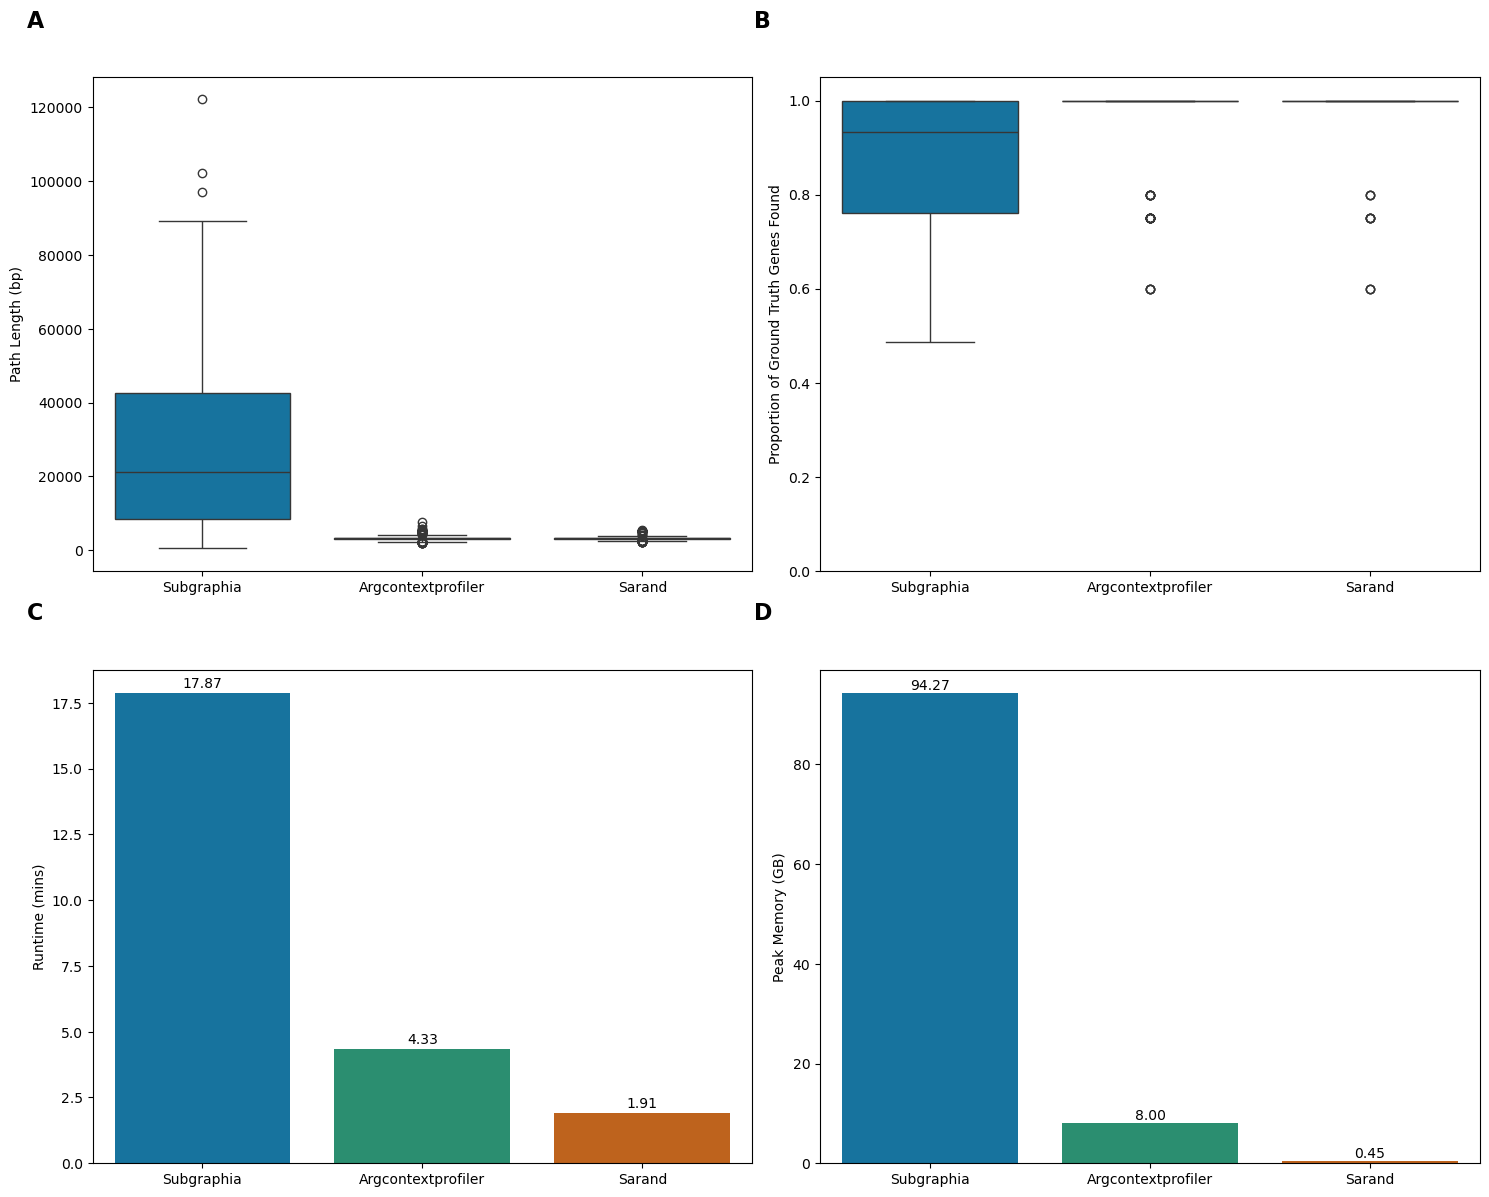

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# benchmarking figures for zymobiomics data

# read in Subgraphia data
## proportion-query-genes-found
fai_subgraphia_zym = pd.read_csv('../fai_correctness/RZ_SR_fai_out.tsv', sep='\t')
fai_subgraphia_zym['Dataset'] = 'ZymoBIOMICS Mock Community'
fai_subgraphia_zym['Tool'] = 'Subgraphia'
## print median proportion-query-genes-found for Subgraphia on ZymoBIOMICS Mock Community
median_proportion_query_genes_found_subgraphia_zym = fai_subgraphia_zym['proportion-query-genes-found'].median()
print(f"Median proportion of ground truth genes found for Subgraphia on ZymoBIOMICS Mock Community: {median_proportion_query_genes_found_subgraphia_zym}")


## length 
subgraphia_zym_summarized = pd.read_csv('../summarized_metadata/zym_SR_summarized.tsv', sep='\t')

# keep only the "length" and "dataset" columns
subgraphia_zym_lengths = subgraphia_zym_summarized[['path_length', 'dataset']]
# rename "path_length" column to "length"
subgraphia_zym_lengths = subgraphia_zym_lengths.rename(columns={'path_length': 'length'})
# print median path length
median_length_subgraphia_zym = subgraphia_zym_lengths['length'].median()
print(f"Median path length for Subgraphia on ZymoBIOMICS Mock Community: {median_length_subgraphia_zym}")

## runtime (mins)
subG_time = 17.87

## memory (GB)

subG_trace = pd.read_csv('subgraphia_RZ_trace.tsv', sep='\t')
peak_RSS_subg = subG_trace['peak_rss'].max() / (1024 * 1024 * 1024)  # convert from bytes to GB
print(f"Peak RSS for SubGraphia: {peak_RSS_subg:.2f} GB")




# read in Argcontextprofiler data
## proportion-query-genes-found
fai_AGCP_zym = pd.read_csv('ARGCP_RZ_fai_out.tsv', sep='\t')
fai_AGCP_zym['Dataset'] = 'ZymoBIOMICS Mock Community'
fai_AGCP_zym['Tool'] = 'Argcontextprofiler'
## print median proportion-query-genes-found for Argcontextprofiler on ZymoBIOMICS Mock Community
median_proportion_query_genes_found_AGCP_zym = fai_AGCP_zym['proportion-query-genes-found'].median()
print(f"Median proportion of ground truth genes found for Argcontextprofiler on ZymoBIOMICS Mock Community: {median_proportion_query_genes_found_AGCP_zym}")

## length
AGCP_lengths = pd.read_csv('ARGCP_RZ_lengths.tsv', sep='\t', header=None, names=['name', 'length'])
AGCP_lengths['dataset'] = 'Argcontextprofiler'
AGCP_lengths = AGCP_lengths[['length', 'dataset']]
# print median path length
median_length_AGCP = AGCP_lengths['length'].median()
print(f"Median path length for Argcontextprofiler on ZymoBIOMICS Mock Community: {median_length_AGCP}")

## runtime (mins)
AGCP_time = 4.332

## memory (GB)
AGCP_mem = 8


# read in Sarand data
## proportion-query-genes-found
fai_sarand_RZ = pd.read_csv('sarand_RZ_SR_fai_out.tsv', sep='\t')
fai_sarand_RZ['Dataset'] = 'ZymoBIOMICS Mock Community'
fai_sarand_RZ['Tool'] = 'Sarand'
# print median proportion-query-genes-found for Sarand on ZymoBIOMICS Mock Community
median_proportion_query_genes_found_sarand_RZ = fai_sarand_RZ['proportion-query-genes-found'].median()
print(f"Median proportion of ground truth genes found for Sarand on ZymoBIOMICS Mock Community: {median_proportion_query_genes_found_sarand_RZ}")

## length
sarand_length_RZ = pd.read_csv('sarand_RZ_lengths.tsv', sep='\t', header=None, names=['name', 'length'])
sarand_length_RZ['dataset'] = 'ZymoBIOMICS Mock Community'
## print median path length
median_length_sarand_RZ = sarand_length_RZ['length'].median()
print(f"Median path length for Sarand on ZymoBIOMICS Mock Community: {median_length_sarand_RZ}")

## runtime (mins)
sar_time = 1.91

## memory (GB)
sar_mem = 0.45

# combine data into query_genes_found_df, length_df, runtime_df, memory_df for plotting

#create list of subgraphia query genes found, argcontextprofiler query genes found, and sarand query genes found
subg_query_genes_found = fai_subgraphia_zym['proportion-query-genes-found']
argconpro_genes_found = fai_AGCP_zym['proportion-query-genes-found']
sarand_genes_found = fai_sarand_RZ['proportion-query-genes-found']
# combine lists to create query_genes_found_df
query_genes_found_df = pd.DataFrame({
    'Subgraphia': subg_query_genes_found,
    'Argcontextprofiler': argconpro_genes_found,
    'Sarand': sarand_genes_found
})


# create lists of subgraphia lengths, argcontextprofiler lengths, and sarand lengths
subg_lengths = subgraphia_zym_lengths['length']
argconpro_lengths = AGCP_lengths['length']
sarand_lengths = sarand_length_RZ['length']
# combine lists to create length_df
length_df = pd.DataFrame({
    'Subgraphia': subg_lengths,
    'Argcontextprofiler': argconpro_lengths,
    'Sarand': sarand_lengths
})

runtime_df = pd.DataFrame({
    'Subgraphia': [subG_time],
    'Argcontextprofiler': [AGCP_time],
    'Sarand': [sar_time]
})

memory_df = pd.DataFrame({
    'Subgraphia': [peak_RSS_subg],
    'Argcontextprofiler': [AGCP_mem],
    'Sarand': [sar_mem]
})

tool_palette = ['#007bb4ff','#1B9E77FF', '#D95F02FF']
# create a four panel figure with proportion-query-genes-found, length, runtime and memory, label with A, B, C, D in the top left corner of each panel, and save as a png
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
# add labels to each panel
axs[0, 0].text(-0.1, 1.1, 'A', transform=axs[0, 0].transAxes, fontsize=16, fontweight='bold')
axs[0, 1].text(-0.1, 1.1, 'B', transform=axs[0, 1].transAxes, fontsize=16, fontweight='bold')
axs[1, 0].text(-0.1, 1.1, 'C', transform=axs[1, 0].transAxes, fontsize=16, fontweight='bold')
axs[1, 1].text(-0.1, 1.1, 'D', transform=axs[1, 1].transAxes, fontsize=16, fontweight='bold')
sns.boxplot(data=query_genes_found_df, ax=axs[0, 1], palette=tool_palette)
axs[0, 1].set_xlabel('')
axs[0, 1].set_ylim(0, 1.05)
axs[0, 1].set_ylabel('Proportion of Ground Truth Genes Found')
#boxplot for length
sns.boxplot(data=length_df, ax=axs[0, 0], palette=tool_palette)
axs[0, 0].set_xlabel('')
axs[0, 0].set_ylabel('Path Length (bp)') 

sns.barplot(data=runtime_df, ax=axs[1, 0], palette=tool_palette)
# add labels to the bars with the runtime values
for i, v in enumerate(runtime_df.iloc[0]):
    axs[1, 0].text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontsize=10)
axs[1, 0].set_xlabel('')
axs[1, 0].set_ylabel('Runtime (mins)')
sns.barplot(data=memory_df, ax=axs[1, 1], palette=tool_palette)
# add labels to the bars with the memory values
for i, v in enumerate(memory_df.iloc[0]):
    axs[1, 1].text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontsize=10)
axs[1, 1].set_xlabel('')
axs[1, 1].set_ylabel('Peak Memory (GB)')

## save figure
plt.tight_layout()
plt.savefig('../figures_tables/figure_S6.png', dpi=300)